# L5 · PSC 거더 — 강도가 남는데 왜 단면이 커지는가

## 이 시간에 답할 질문

철근콘크리트 보는 **극한한계상태**가 단면을 정한다. 휨강도가 모자라면
철근을 늘리고, 그래도 모자라면 단면을 키운다. 사용성은 대개 나중에
확인만 한다.

PSC 거더는 그렇지 않다. 이 강의에서 계산해 보면, 30 m 거더의 설계
휨강도는 소요값의 **1.01 배**로 아슬아슬한데, 45 m 거더는 **1.11 배**로
여유가 있다. 그런데도 45 m 거더가 강연선을 더 넣어야 한다.
**강도가 남는데 단면이 결정되지 않는 것이다.**

1. 프리스트레스는 넣은 만큼 남지 않는다. 어디로, 얼마나 사라지는가?
2. 편심은 클수록 좋은가? 그렇다면 왜 실제 거더는 텐던을 휘어 놓는가?
3. 지간이 길어지면 어느 순간 지배하는 한계상태가 바뀐다. 언제, 왜?
4. 같은 거더를 KDS 14 로 풀면 얼마나 다른가?

## 근거 조문

| 내용 | 조문 |
|---|---|
| 긴장 시 최대 응력 식 $(1.5\text{-}7)$ | KDS 24 14 21 1.5.7.2 |
| 도입 직후 응력 식 $(1.5\text{-}9)$ | KDS 24 14 21 1.5.7.3 |
| 긴장 시 콘크리트 압축 한계 식 $(1.5\text{-}8)$ | KDS 24 14 21 1.5.7.3 |
| 마찰 손실 식 $(1.5\text{-}11)$, 표 1.5-2 | KDS 24 14 21 1.5.7.4 |
| 탄성변형 손실 식 $(1.5\text{-}10)$ | KDS 24 14 21 1.5.7.4 |
| 릴랙세이션 식 $(3.3\text{-}1)\sim(3.3\text{-}3)$ | KDS 24 14 21 3.3.2(7) |
| 장기 손실 식 $(1.5\text{-}12)$ | KDS 24 14 21 1.5.7.5 |
| 사용한계상태 응력 한계, 표 4.2-2 | KDS 24 14 21 4.2.2 |
| 극한한계상태 휨 | KDS 24 14 21 4.1.1 |

:::{warning}
이 강의가 쓰는 :data:`EXAMPLE_SECTIONS` 는 **예시 단면이며 어떤
표준도도 아니다.** 형상은 일반적인 PSC I형 거더를 본떴을 뿐이므로,
실제 설계에는 해당 표준도나 제작사 제원을 써야 한다.
:::

:::{tip}
같은 내용을 슬라이더로 움직여 보려면
[대화형 탐색기](../_static/explorer.html)를 연다. 값을 바꾸면 그래프가 바로
따라 바뀐다.
:::

## 0. 준비

**아래 코드가 하는 일** — 한글 글꼴을 등록하고 그림 색을 정한다.

In [1]:
%matplotlib inline

import glob
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager


def use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다."""
    site = Path(sys.prefix, "lib", f"python{sys.version_info.major}.{sys.version_info.minor}", "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Malgun Gothic", "AppleGothic",
                 "Noto Sans CJK KR", "Noto Sans KR", "WenQuanYi Zen Hei"):
        if name in installed:
            plt.rcParams["font.family"] = name
            return name

    warnings.warn(
        "한글 글꼴을 찾지 못했다. 그림의 한글이 깨진다면 "
        "`pip install koreanize-matplotlib` 로 글꼴만 내려받거나, "
        "나눔고딕·Noto Sans KR 을 시스템에 설치한다.",
        stacklevel=2,
    )
    return None


print("사용 글꼴:", use_korean_font())

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 단면 분류에 쓰는 색 (압축지배 · 변화구간 · 인장지배)
C_COMP, C_TRAN, C_TENS = "#ad3327", "#b5811f", "#2a7355"
BAND = {"압축지배단면": C_COMP, "변화구간단면": C_TRAN, "인장지배단면": C_TENS}

사용 글꼴: NanumGothic


**아래 코드가 하는 일** — 거더 설계 함수를 불러오고 기준 조건을 정한다.
형고 2.0 m 의 PSC I형 거더를 지간 30 m 에 거더 간격 2.5 m 로 놓고,
15.2 mm 강연선 25 가닥을 넣은 경우다.

In [2]:
from concreteproperties_kds.kds import stress_block_parameters
from concreteproperties_kds.kds24 import (
    EXAMPLE_SECTIONS,
    GAMMA_CONCRETE,
    TENDON_COVER,
    characteristic_tensile_strength,
    design_compressive_strength,
    design_girder,
    design_yield_strength,
    equivalent_block,
    girder_live_load,
    max_jacking_stress,
)

STRAND = 138.7   # 15.2 mm 7연선 1가닥의 단면적 (mm2)
FPU, FPY = 1860.0, 1600.0

# 기준 조건 — 앞으로 이 값을 하나씩 바꿔 가며 비교한다
SECTION = EXAMPLE_SECTIONS["PSC-I 2.0m"]   # 거더 단면      <- 바꿔 보라
SPAN = 30.0                                # 지간 (m)       <- 바꿔 보라
STRANDS = 25                               # 강연선 가닥 수  <- 바꿔 보라

BASE = dict(section=SECTION, span=SPAN, a_p=STRANDS * STRAND)

C_JACK = "#5b6472"
C_LOSS = "#b3372c"
C_EFF = "#1f6feb"
C_CAP = "#1f7a4d"
C_K14 = "#b3372c"

props = SECTION.properties()
print(f"{SECTION.name}:  A = {props.area / 1e6:.3f} m2,  "
      f"y_b = {props.y_b:.0f} mm,  I = {props.inertia / 1e12:.4f} m4")
print(f"기본 편심 e = y_b - {TENDON_COVER:.0f} = {props.y_b - TENDON_COVER:.0f} mm")

PSC-I 2.0m:  A = 0.881 m2,  y_b = 962 mm,  I = 0.4176 m4
기본 편심 e = y_b - 200 = 762 mm


## 1. 넣은 만큼 남지 않는다

프리스트레스 설계가 철근콘크리트와 결정적으로 다른 점은 **넣은 힘이
시간이 지나면 줄어든다**는 것이다. 철근은 넣어 두면 그대로 있지만,
긴장재는 그렇지 않다.

기준은 손실을 두 묶음으로 나눈다.

**즉시 손실** — 긴장하는 그 순간에 이미 생긴다.

- **마찰** 식 $(1.5\text{-}11)$: 덕트 안에서 강연선이 끌리며 잃는다.
  곡률각 $\theta$ 와 길이 $x$ 에 지수적으로 붙는다.
- **정착장치 활동**: 쐐기를 물릴 때 강연선이 몇 mm 끌려 들어간다.
- **탄성변형** 식 $(1.5\text{-}10)$: 긴장하면 콘크리트가 줄고, 그만큼
  이미 정착된 강연선도 같이 줄어 응력을 잃는다.

**장기 손실** 식 $(1.5\text{-}12)$ — 몇 년에 걸쳐 진행된다.

- **크리프**: 압축을 받은 콘크리트가 계속 줄어든다.
- **건조수축**: 콘크리트가 마르며 줄어든다.
- **릴랙세이션** 식 $(3.3\text{-}2)$: 강연선 자체가 늘어난 채로
  응력을 잃는다.

**아래 코드가 하는 일** — 손실을 항목별로 계산해 표로 찍는다.

In [3]:
result = design_girder(**BASE)
losses = result.losses

print(f"긴장응력  f_jack = {losses.f_jack:7.1f} MPa"
      f"   = min(0.8 x {FPU:.0f}, 0.9 x {FPY:.0f})")
print("-" * 58)
items = [
    ("마찰", losses.friction),
    ("정착장치 활동", losses.anchorage),
    ("탄성변형", losses.elastic),
]
for name, value in items:
    print(f"  {name:14s} -{value:6.1f} MPa   "
          f"({value / losses.f_jack * 100:5.2f} %)")
print(f"도입 직후 f_pi   = {losses.f_pi:7.1f} MPa"
      f"   즉시손실 {losses.immediate_ratio * 100:5.2f} %")
print("-" * 58)
print(f"  {'장기(크리프+건조수축+릴랙세이션)':s} "
      f"-{losses.long_term:.1f} MPa "
      f"({losses.long_term / losses.f_jack * 100:.2f} %)")
print(f"유효응력  f_pe   = {losses.f_pe:7.1f} MPa"
      f"   총손실   {losses.total_ratio * 100:5.2f} %")
print("-" * 58)
print(f"P_i = {result.p_i / 1e3:6.0f} kN"
      f"      P_e = {result.p_e / 1e3:6.0f} kN")

긴장응력  f_jack =  1440.0 MPa   = min(0.8 x 1860, 0.9 x 1600)
----------------------------------------------------------
  마찰             - 114.4 MPa   ( 7.95 %)
  정착장치 활동        -  40.0 MPa   ( 2.78 %)
  탄성변형           -  30.7 MPa   ( 2.13 %)
도입 직후 f_pi   =  1254.9 MPa   즉시손실 12.86 %
----------------------------------------------------------
  장기(크리프+건조수축+릴랙세이션) -116.4 MPa (8.08 %)
유효응력  f_pe   =  1138.5 MPa   총손실   20.94 %
----------------------------------------------------------
P_i =   4351 kN      P_e =   3948 kN


**읽는 법** — 긴장할 때 1,440 MPa 를 걸었는데 최종적으로 남는 것은
1,138 MPa 다. **21 % 가 사라진다.** 그리고 그중 가장 큰 몫은 크리프도
건조수축도 아닌 **마찰(8.0 %)** 이다.

이것이 실무에서 중요한 이유가 있다. 크리프와 건조수축은 재료와 환경이
정하므로 설계자가 크게 손댈 수 없다. 그러나 마찰은 **텐던 배치가
정한다.** 곡률을 줄이거나, 양쪽에서 긴장하거나, 윤활 덕트를 쓰면
(표 1.5-2 에서 $\mu$ 가 0.19 → 0.12) 줄일 수 있다. 설계자가 실제로
움직일 수 있는 손실이 가장 큰 손실인 셈이다.

**아래 코드가 하는 일** — 손실을 폭포 그림으로 그려 어디서 얼마가
빠지는지 한눈에 보인다.

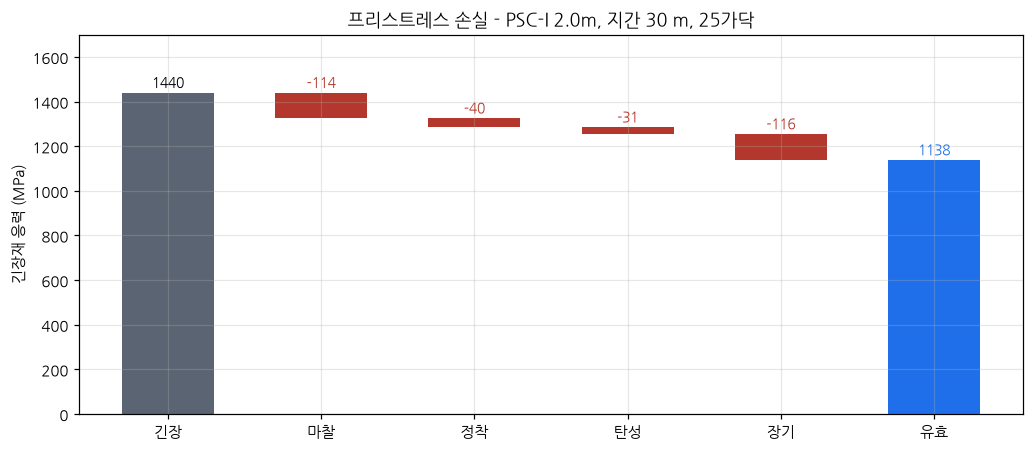

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))

names = ["긴장", "마찰", "정착", "탄성", "장기", "유효"]
deltas = [losses.friction, losses.anchorage,
          losses.elastic, losses.long_term]

level = losses.f_jack
ax.bar(0, level, color=C_JACK, width=0.6)
ax.text(0, level + 25, f"{level:.0f}", ha="center", fontsize=9)

for i, d in enumerate(deltas, start=1):
    ax.bar(i, d, bottom=level - d, color=C_LOSS, width=0.6)
    ax.text(i, level + 25, f"-{d:.0f}", ha="center",
            fontsize=9, color=C_LOSS)
    level -= d

ax.bar(5, level, color=C_EFF, width=0.6)
ax.text(5, level + 25, f"{level:.0f}", ha="center",
        fontsize=9, color=C_EFF)

ax.set_xticks(range(6))
ax.set_xticklabels(names)
ax.set_ylabel("긴장재 응력 (MPa)")
ax.set_title(f"프리스트레스 손실 - {SECTION.name}, 지간 {SPAN:.0f} m, "
             f"{STRANDS}가닥")
ax.set_ylim(0, losses.f_jack * 1.18)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 2. 도입응력의 상한은 왜 $f_{py}$ 가 정하는가

식 $(1.5\text{-}7)$ 은 긴장 시 최대 응력을 이렇게 준다.

$$
f_{o,\max} = \min(0.80 f_{pu},\; 0.90 f_{py})
$$

SWPC 7B 15.2 mm 강연선은 $f_{pu} = 1{,}860$, $f_{py} = 1{,}600$ MPa 다.
넣어 보면 $0.80 \times 1860 = 1488$, $0.90 \times 1600 = 1440$ 이므로
**항복강도 조건이 지배한다.**

두 조건이 하는 일이 다르다. $0.80 f_{pu}$ 는 **끊어지지 않게** 하는
조건이고, $0.90 f_{py}$ 는 **항복하지 않게** 하는 조건이다. 긴장재가
항복해 버리면 프리스트레스가 힘을 잃으므로, 파단보다 항복이 먼저
막아야 할 사건이다.

**아래 코드가 하는 일** — 강재 종류를 바꿔 가며 어느 조건이 지배하는지
본다.

In [5]:
print(f"{'강재':16s} {'f_pu':>7} {'f_py':>7} "
      f"{'0.8f_pu':>9} {'0.9f_py':>9} {'지배':>10}")
print("-" * 64)
for name, fpu, fpy in [
    ("SWPC 7B (일반)", 1860.0, 1600.0),
    ("f_py 가 높은 강재", 1860.0, 1750.0),
    ("f_py/f_pu = 0.85", 1860.0, 1581.0),
]:
    a, b = 0.80 * fpu, 0.90 * fpy
    governs = "0.8 f_pu" if a < b else "0.9 f_py"
    print(f"{name:16s} {fpu:7.0f} {fpy:7.0f} {a:9.0f} {b:9.0f} "
          f"{governs:>10}")

print()
print("두 조건이 같아지는 항복비:  0.8 f_pu = 0.9 f_py")
print(f"  ->  f_py / f_pu = 0.8 / 0.9 = {0.8 / 0.9:.4f}")
print("항복비가 이보다 낮으면 f_py 조건이, 높으면 f_pu 조건이 지배한다.")

강재                  f_pu    f_py   0.8f_pu   0.9f_py         지배
----------------------------------------------------------------
SWPC 7B (일반)        1860    1600      1488      1440   0.9 f_py
f_py 가 높은 강재        1860    1750      1488      1575   0.8 f_pu
f_py/f_pu = 0.85    1860    1581      1488      1423   0.9 f_py

두 조건이 같아지는 항복비:  0.8 f_pu = 0.9 f_py
  ->  f_py / f_pu = 0.8 / 0.9 = 0.8889
항복비가 이보다 낮으면 f_py 조건이, 높으면 f_pu 조건이 지배한다.


**읽는 법** — 경계는 항복비 $f_{py}/f_{pu} = 0.889$ 다. 보통 강연선의
항복비는 0.85 ~ 0.86 이므로 **거의 항상 $0.90 f_{py}$ 가 지배한다.**
$f_{pu}$ 조건은 사실상 예비 조건인 셈이다.

## 3. 편심은 클수록 좋은가

프리스트레스가 휨에 저항하는 원리는 **편심 모멘트** $P \cdot e$ 다.
같은 힘이라도 도심에서 멀리 걸수록 큰 모멘트를 만든다. 그러면 편심을
최대한 키우면 되지 않는가?

**아래 코드가 하는 일** — 편심만 바꿔 가며 응력과 휨강도를 본다.

In [6]:
print(f"{'e (mm)':>8} {'긴장 상연':>10} {'긴장 하연':>10} "
      f"{'사용 하연':>10} {'M_Rd':>9}  판정")
print("-" * 62)

eccentricities = [300, 400, 500, 600, 700,
                  props.y_b - TENDON_COVER, 850]
for e in eccentricities:
    r = design_girder(**{**BASE, "eccentricity": float(e)})
    failed = [k for k, v in r.checks.items() if not v]
    verdict = "OK" if r.adequate else ", ".join(failed)
    mark = " <- 기본값" if abs(e - (props.y_b - TENDON_COVER)) < 1 else ""
    print(f"{e:8.0f} {r.stresses['긴장 직후'][0]:10.2f} "
          f"{r.stresses['긴장 직후'][1]:10.2f} "
          f"{r.stresses['사용'][1]:10.2f} {r.m_rd:9.0f}  "
          f"{verdict}{mark}")

  e (mm)      긴장 상연      긴장 하연      사용 하연      M_Rd  판정
--------------------------------------------------------------
     300       7.75       2.44      -6.53      7783  지속하중 영응력, 사용 비균열, 설계휨강도
     400       6.65       3.44      -5.59      8282  지속하중 영응력, 사용 비균열, 설계휨강도
     500       5.56       4.44      -4.67      8781  지속하중 영응력, 사용 비균열, 설계휨강도


     600       4.48       5.42      -3.77      9281  사용 비균열, 설계휨강도
     700       3.40       6.39      -2.89      9780  사용 비균열, 설계휨강도
     762       2.73       6.99      -2.37     10091  OK <- 기본값
     850       1.80       7.82      -1.65     10529  OK


**읽는 법** — 편심을 키울수록 사용 시 하연 인장이 줄고($-6.53 \to
-1.65$ MPa) 휨강도도 는다(7,783 → 10,529 kN·m). **지간 중앙만 보면
편심은 클수록 좋다.** 상한은 응력이 아니라 하부플랜지 안에 강연선을
넣을 자리가 있느냐는 **기하학적 제약**이다.

그런데 실제 PSC 거더의 텐던은 곧지 않다. 단부로 갈수록 위로 휘어
올라간다. 왜인가?

**지간 중앙에서 편심이 유리했던 이유는 자중 모멘트가 있었기
때문이다.** 프리스트레스가 상연에 만드는 인장을 자중이 상쇄해 주었다.
그런데 **단부에서는 자중 모멘트가 0 이다.** 상쇄해 줄 것이 없다.

**아래 코드가 하는 일** — 단부 단면에서 편심에 따른 상연 응력을 본다.

In [7]:
z_t = props.inertia / props.y_t
kern = z_t / props.area           # 핵거리 - 이 안이면 전단면 압축
f_ctk_transfer = characteristic_tensile_strength(fck=30.0)

print(f"단부 단면 (자중 모멘트 = 0),  P_i = {result.p_i / 1e3:.0f} kN")
print(f"{'e (mm)':>8} {'상연 응력 (MPa)':>16}   상태")
print("-" * 46)
for e in (300, 400, kern, 500, 600, props.y_b - TENDON_COVER):
    top = result.p_i / props.area - result.p_i * e / z_t
    if top >= 0:
        state = "압축"
    elif -top <= f_ctk_transfer:
        state = "인장 (균열 전)"
    else:
        state = "인장 - 균열!"
    print(f"{e:8.0f} {top:16.2f}   {state}")

print()
print(f"핵거리  Z_t / A = {kern:.0f} mm")
print(f"긴장 시 f_ctk (f_ck = 30) = {f_ctk_transfer:.2f} MPa")
print(f"중앙 편심 {props.y_b - TENDON_COVER:.0f} mm 를 단부까지 "
      f"그대로 끌고 가면 상연 인장이 "
      f"{abs(result.p_i / props.area - result.p_i * (props.y_b - TENDON_COVER) / z_t):.2f} MPa "
      f"로 f_ctk 를 넘는다.")

단부 단면 (자중 모멘트 = 0),  P_i = 4351 kN
  e (mm)      상연 응력 (MPa)   상태
----------------------------------------------
     300             1.70   압축
     400             0.61   압축
     457             0.00   압축
     500            -0.47   인장 (균열 전)
     600            -1.55   인장 (균열 전)
     762            -3.30   인장 - 균열!

핵거리  Z_t / A = 457 mm
긴장 시 f_ctk (f_ck = 30) = 2.20 MPa
중앙 편심 762 mm 를 단부까지 그대로 끌고 가면 상연 인장이 3.30 MPa 로 f_ctk 를 넘는다.


**읽는 법** — 여기서 **핵거리** $Z_t/A = 457$ mm 가 나온다. 편심이 이
안에 있으면 단면 전체가 압축이고, 넘으면 상연에 인장이 생긴다.

중앙에서 쓰는 편심 762 mm 를 단부까지 그대로 끌고 가면 상연 인장이
**3.30 MPa** 로, 긴장 시 인장강도 $f_{ctk} = 2.20$ MPa 를 넘어
**거더 단부 상연이 갈라진다.**

그래서 텐던을 **드레이프**(휘어 올림)하거나 일부를 **디본딩**한다.
이것은 시공 편의가 아니라 **응력이 요구하는 형상**이다. 중앙에서는
편심이 커야 하고 단부에서는 핵 안으로 들어와야 하니, 그 사이를 잇는
곡선이 곧 텐던 배치도가 된다.

**아래 코드가 하는 일** — 지간을 따라 필요한 편심의 위·아래 한계를
그려 텐던이 지나야 할 통로를 보인다.

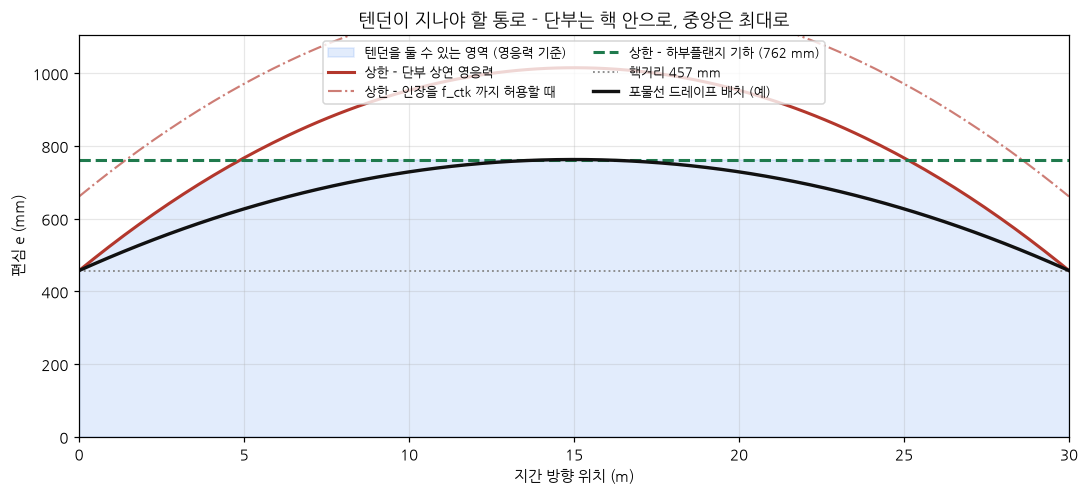

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.6))

x = np.linspace(0, SPAN, 200)
w_self = GAMMA_CONCRETE * props.area / 1e6
m_self = w_self * x * (SPAN - x) / 2.0        # 자중 모멘트 (kN.m)

z_b = props.inertia / props.y_b
p = result.p_i

# 긴장 직후 상연 응력이 한계를 지킬 편심의 상한.
#   P/A - P e / Z_t + M_self / Z_t >= -f_lim   을 e 에 대해 푼 것
def upper(f_lim):
    return z_t / props.area + (m_self * 1e6 + f_lim * z_t) / p

e_zero = upper(0.0)              # 영응력 - design_girder 가 쓰는 검토
e_crack = upper(f_ctk_transfer)  # f_ctk 까지 허용하면 여기까지
e_geom = props.y_b - TENDON_COVER

ax.fill_between(x, 0, np.minimum(e_zero, e_geom),
                color=C_EFF, alpha=0.13,
                label="텐던을 둘 수 있는 영역 (영응력 기준)")
ax.plot(x, e_zero, color=C_LOSS, lw=2,
        label="상한 - 단부 상연 영응력")
ax.plot(x, e_crack, color=C_LOSS, lw=1.4, ls="-.", alpha=0.65,
        label="상한 - 인장을 f_ctk 까지 허용할 때")
ax.axhline(e_geom, color=C_CAP, lw=2, ls="--",
           label=f"상한 - 하부플랜지 기하 ({e_geom:.0f} mm)")
ax.axhline(kern, color="#888", lw=1.2, ls=":",
           label=f"핵거리 {kern:.0f} mm")

# 전형적인 2차 포물선 드레이프
e_drape = kern + (e_geom - kern) * (1 - (1 - 2 * x / SPAN) ** 2)
ax.plot(x, e_drape, color="#111", lw=2.2,
        label="포물선 드레이프 배치 (예)")

ax.set_xlabel("지간 방향 위치 (m)")
ax.set_ylabel("편심 e (mm)")
ax.set_title("텐던이 지나야 할 통로 - 단부는 핵 안으로, 중앙은 최대로")
ax.set_xlim(0, SPAN)
ax.set_ylim(0, e_geom * 1.45)
ax.legend(fontsize=8.5, loc="upper center", ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**읽는 법** — 파란 영역이 텐던을 둘 수 있는 자리다. 단부(x = 0)에서
상한은 정확히 **핵거리 457 mm** 다. 자중 모멘트가 0 이니 식이
$Z_t/A$ 로 줄어들기 때문이다. 중앙으로 갈수록 자중 모멘트가 상한을
밀어올려 넓어지고, 결국 **응력이 아니라 하부플랜지의 기하**가
상한이 된다.

점선(-·-)은 인장을 $f_{ctk}$ 까지 허용했을 때의 상한이다. 단부에서
667 mm 까지 올라간다. 어느 쪽을 쓰느냐는 **설계등급이 정한다** —
표 4.2-2 에서 긴장 직후 영응력을 요구하는 등급이면 실선이,
균열폭 제한만 요구하는 등급이면 점선이 상한이 된다. 이 강의의
`design_girder` 는 보수적인 쪽(영응력)을 쓴다.

검은 선이 전형적인 포물선 드레이프다. 이 곡선이 통로 안에 있으면
배치가 성립한다. **텐던을 휘는 것은 관행이 아니라 이 그림이 시키는
일이다.**

## 4. 합성 단면이 하는 일

PSC 거더교는 보통 **거더를 먼저 놓고 바닥판을 나중에 친다.** 그래서
하중마다 저항하는 단면이 다르다.

| 하중 | 저항 단면 |
|---|---|
| 거더 자중 | 거더 단독 |
| 굳지 않은 바닥판 콘크리트 | 거더 단독 |
| 2차 고정하중 (포장·방호벽) | 합성 단면 |
| 활하중 | 합성 단면 |

굳지 않은 바닥판은 하중이지 단면이 아니다. 이 순서를 지키지 않고
전부 합성 단면으로 풀면 **거더 단독으로 버텨야 하는 시기를 놓친다.**

**아래 코드가 하는 일** — 거더 단독과 합성 단면의 성질을 비교한다.

In [9]:
e_ratio = 0.86   # 바닥판/거더 탄성계수비 (f_ck 27 / 40)
composite = SECTION.composite(
    deck_width=2500.0, deck_thickness=240.0,
    modular_ratio=e_ratio, haunch=50.0,
)

print(f"{'':10} {'A (m2)':>9} {'y_b (mm)':>10} "
      f"{'I (m4)':>9} {'Z_b (m3)':>10} {'Z_t (m3)':>10}")
print("-" * 62)
for label, s in [("거더 단독", props), ("합성 단면", composite)]:
    print(f"{label:10} {s.area / 1e6:9.3f} {s.y_b:10.0f} "
          f"{s.inertia / 1e12:9.4f} {s.z_b / 1e9:10.4f} "
          f"{s.z_t / 1e9:10.4f}")

print()
print(f"합성으로 Z_b 가 {composite.z_b / props.z_b:.2f} 배가 된다.")
print("-> 합성 후에 실리는 하중은 하연 인장을 그만큼 덜 만든다.")

span_m = SPAN
w_deck = GAMMA_CONCRETE * 2.5 * 0.240
m_girder = GAMMA_CONCRETE * props.area / 1e6 * span_m**2 / 8
m_deck = w_deck * span_m**2 / 8
m_sdl = 3.0 * span_m**2 / 8
m_live = girder_live_load(span=span_m).moment * 0.6

print()
print("하중별 휨모멘트 (비계수, kN.m)")
total = m_girder + m_deck + m_sdl + m_live
for label, m, s in [
    ("거더 자중", m_girder, "거더"),
    ("바닥판", m_deck, "거더"),
    ("2차 고정하중", m_sdl, "합성"),
    ("활하중+충격", m_live, "합성"),
]:
    print(f"  {label:14s} {m:8.0f}  ({m / total * 100:4.1f} %)  "
          f"저항 단면: {s}")
print(f"  {'합계':14s} {total:8.0f}")
print(f"  거더 단독이 받는 몫: "
      f"{(m_girder + m_deck) / total * 100:.1f} %")

              A (m2)   y_b (mm)    I (m4)   Z_b (m3)   Z_t (m3)
--------------------------------------------------------------
거더 단독          0.881        962    0.4176     0.4340     0.4024
합성 단면          1.397       1408    0.8947     0.6352     1.0148

합성으로 Z_b 가 1.46 배가 된다.
-> 합성 후에 실리는 하중은 하연 인장을 그만큼 덜 만든다.

하중별 휨모멘트 (비계수, kN.m)
  거더 자중              2428  (35.3 %)  저항 단면: 거더
  바닥판                1654  (24.1 %)  저항 단면: 거더
  2차 고정하중             338  ( 4.9 %)  저항 단면: 합성
  활하중+충격             2456  (35.7 %)  저항 단면: 합성
  합계                 6876
  거더 단독이 받는 몫: 59.4 %


**읽는 법** — 합성으로 하연 단면계수가 **1.46 배**가 된다. 그런데
전체 하중의 **59 %** 는 그 혜택을 못 받는다. 거더 자중과 바닥판이
합성 전에 이미 실리기 때문이다.

이것이 PSC 거더 설계의 핵심 제약이다. 큰 단면계수는 나중에나 생기는데,
가장 불리한 순간(긴장 직후)은 가장 작은 단면으로 버텨야 한다.

## 5. 지간이 길어지면 무엇이 바뀌는가

이제 처음의 질문으로 돌아간다. 지간별로 **최소 강연선 수량**을 구하고,
그때 무엇이 그 수량을 정했는지 본다.

**아래 코드가 하는 일** — 지간마다 가닥 수를 1 개씩 늘려 가며 모든
한계상태를 만족하는 최소값을 찾고, 한 가닥 모자랄 때 무엇이 깨지는지
기록한다.

In [10]:
CASES = [
    ("PSC-I 1.4m", 20.0),
    ("PSC-I 1.7m", 25.0),
    ("PSC-I 2.0m", 30.0),
    ("PSC-I 2.0m", 35.0),
    ("PSC-I 2.3m", 40.0),
    ("PSC-I 2.7m", 45.0),
    ("PSC-I 2.7m", 50.0),
]

table = []
for name, span in CASES:
    section = EXAMPLE_SECTIONS[name]
    for n in range(6, 141):
        r = design_girder(section=section, span=span, a_p=n * STRAND)
        if r.adequate:
            break
    short = design_girder(section=section, span=span,
                          a_p=(n - 1) * STRAND)
    governing = [k for k, v in short.checks.items() if not v]
    table.append((name, span, n, r, governing))

print(f"{'단면':12s} {'지간':>5} {'가닥':>5} {'손실':>7} "
      f"{'M_Rd/M_Ed':>10}  한 가닥 모자랄 때 깨지는 것")
print("-" * 78)
for name, span, n, r, governing in table:
    print(f"{name:12s} {span:5.0f} {n:5d} "
          f"{r.losses.total_ratio * 100:6.1f} % "
          f"{r.m_rd / r.m_ed:10.2f}  {', '.join(governing)}")

단면              지간    가닥      손실  M_Rd/M_Ed  한 가닥 모자랄 때 깨지는 것
------------------------------------------------------------------------------
PSC-I 1.4m      20    16   20.5 %       1.05  설계휨강도
PSC-I 1.7m      25    20   20.5 %       1.01  사용 비균열, 설계휨강도
PSC-I 2.0m      30    25   20.9 %       1.01  사용 비균열, 설계휨강도
PSC-I 2.0m      35    36   23.1 %       1.09  사용 비균열
PSC-I 2.3m      40    42   23.3 %       1.09  사용 비균열
PSC-I 2.7m      45    48   23.7 %       1.11  사용 비균열
PSC-I 2.7m      50    61   25.5 %       1.14  사용 비균열


**읽는 법** — 전환이 뚜렷하다.

- **20 m** — 극한 휨강도만 깨진다. 강도가 정한다.
- **25 ~ 30 m** — 둘이 동시에 깨진다. 균형점이다.
- **35 m 이상** — 사용한계상태 균열만 깨진다. **극한 휨강도는 1.09 ~
  1.14 배로 남아도는데도** 강연선을 더 넣어야 한다.

왜 이렇게 되는가? 지간이 길어질 때 두 요구가 같은 속도로 자라지 않기
때문이다.

- 극한 휨강도가 요구하는 것은 **긴장재의 인장력** $A_p f_{pd}$ 다.
  강연선을 늘리면 거의 비례해 는다.
- 사용한계상태가 요구하는 것은 **하연 압축응력** $P/A + Pe/Z_b$ 이고,
  이것을 깎아내리는 것은 $M/Z_b$ 다. 지간이 길어지면 $M$ 은
  $L^2$ 로 느는데 $Z_b$ 는 형고가 허용하는 만큼만 큰다.

게다가 손실도 지간에 따라 는다(20.5 % → 25.5 %). 마찰이 길이에
비례하기 때문이다. **긴 거더는 넣은 힘을 더 많이 잃으면서, 더 많은
힘을 필요로 한다.**

**아래 코드가 하는 일** — 두 한계상태의 여유를 지간에 대해 그린다.

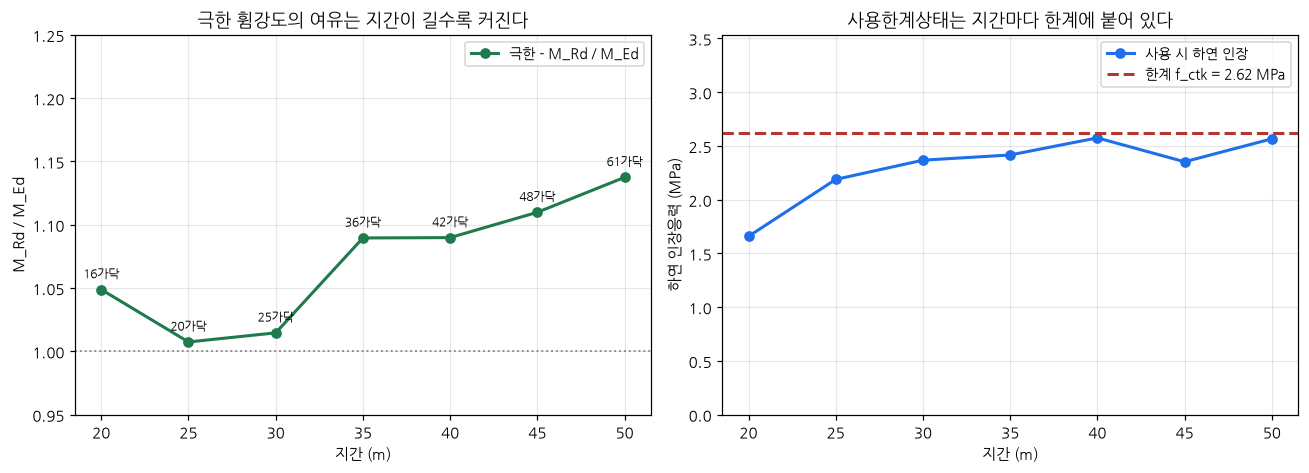

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

spans = [t[1] for t in table]
strands = [t[2] for t in table]
ratio_uls = [t[3].m_rd / t[3].m_ed for t in table]
tension = [-t[3].stresses["사용"][1] for t in table]
f_ctk = characteristic_tensile_strength(fck=40.0)

ax1.plot(spans, ratio_uls, "o-", color=C_CAP, lw=2,
         label="극한 - M_Rd / M_Ed")
ax1.axhline(1.0, color="#888", ls=":", lw=1.2)
ax1.set_xlabel("지간 (m)")
ax1.set_ylabel("M_Rd / M_Ed")
ax1.set_title("극한 휨강도의 여유는 지간이 길수록 커진다")
ax1.set_ylim(0.95, 1.25)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=9)

for x, y, n in zip(spans, ratio_uls, strands):
    ax1.annotate(f"{n}가닥", (x, y), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8)

ax2.plot(spans, tension, "o-", color=C_EFF, lw=2,
         label="사용 시 하연 인장")
ax2.axhline(f_ctk, color=C_LOSS, lw=2, ls="--",
            label=f"한계 f_ctk = {f_ctk:.2f} MPa")
ax2.set_xlabel("지간 (m)")
ax2.set_ylabel("하연 인장응력 (MPa)")
ax2.set_title("사용한계상태는 지간마다 한계에 붙어 있다")
ax2.set_ylim(0, f_ctk * 1.35)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

**읽는 법** — 오른쪽부터 보라. **25 m 이상에서는 사용 시 하연 인장이
한계선($f_{ctk} = 2.62$ MPa)에 거의 닿아 있다.** 한계에 붙어 있는
쪽이 지배하는 쪽이다. 반면 20 m 는 1.66 MPa 로 한계에서 멀다 —
거기서는 사용한계상태가 여유롭고 극한이 단면을 정했다는 뜻이다.

왼쪽에서 극한 여유는 35 m 를 넘으면서 1.09 → 1.14 로 **벌어진다.**
사용한계상태가 요구하는 긴장력이 극한이 요구하는 것보다 커졌기
때문이다.

다만 두 그림 모두 매끄럽지 않다. 20 m 의 1.05, 45 m 의 2.36 처럼
튀는 점이 있는데, 이는 물리가 아니라 **강연선을 정수로만 넣을 수
있어서** 생기는 것이다. 16 가닥에서 한 가닥은 6 % 이므로 필요량을
그만큼 넘겨 버린다. 지간이 길어져 가닥 수가 많아질수록 이 톱니는
작아진다.

## 6. 같은 거더를 KDS 14 로 풀면

L1 ~ L3 에서 본 대로, 두 기준은 **안전율을 거는 자리**가 다르다.
같은 단면의 극한 휨강도를 두 방식으로 계산해 본다.

**아래 코드가 하는 일** — 합성 단면 상연에서 긴장재까지를 유효깊이로
보고, 등가블록으로 두 기준의 휨강도를 각각 계산한다.

In [12]:
d_p = SECTION.height + 50.0 + 240.0 - TENDON_COVER
a_p = STRANDS * STRAND
b_eff = 2500.0
fck_deck = 27.0

# KDS 24 - 재료마다 재료계수
alpha_eq, beta_eq = equivalent_block(fck=fck_deck, phi_c=0.65)
lam = 2.0 * beta_eq
eta24 = alpha_eq / lam
f_cd = design_compressive_strength(fck=fck_deck, phi_c=0.65)
f_pd = design_yield_strength(fy=FPY, phi_s=0.90)
t24 = a_p * f_pd
a24 = t24 / (eta24 * f_cd * b_eff)
m_rd = t24 * (d_p - a24 / 2.0) / 1e6

# KDS 14 - 공칭강도에 강도감소계수 한 번
_, eta14, _ = stress_block_parameters(fck=fck_deck)
t14 = a_p * FPY
a14 = t14 / (eta14 * 0.85 * fck_deck * b_eff)
m_n = t14 * (d_p - a14 / 2.0) / 1e6
phi = 0.85

print(f"유효깊이 d_p = {d_p:.0f} mm,  A_p = {a_p:.0f} mm2,  "
      f"b_eff = {b_eff:.0f} mm")
print()
print(f"{'':8} {'강재 응력':>10} {'콘크리트':>10} {'a (mm)':>9} "
      f"{'강도 (kN.m)':>12}")
print("-" * 56)
print(f"{'KDS 24':8} {f_pd:10.0f} {f_cd:10.2f} {a24:9.0f} "
      f"{m_rd:12.0f}   <- M_Rd")
print(f"{'KDS 14':8} {FPY:10.0f} {eta14 * 0.85 * fck_deck:10.2f} "
      f"{a14:9.0f} {m_n:12.0f}   <- M_n")
print(f"{'':8} {'':10} {'':10} {'x phi=0.85':>9} "
      f"{phi * m_n:12.0f}   <- phi M_n")
print()
print(f"KDS 24 / KDS 14 = {m_rd / (phi * m_n):.3f}  "
      f"({(m_rd / (phi * m_n) - 1) * 100:+.1f} %)")

유효깊이 d_p = 2090 mm,  A_p = 3467 mm2,  b_eff = 2500 mm

              강재 응력       콘크리트    a (mm)    강도 (kN.m)
--------------------------------------------------------
KDS 24         1440      14.92       138        10091   <- M_Rd
KDS 14         1600      22.95        97        11327   <- M_n
                               x phi=0.85         9628   <- phi M_n

KDS 24 / KDS 14 = 1.048  (+4.8 %)


**읽는 법** — KDS 24 가 **4.8 % 크게** 나온다. L2 에서 본 철근콘크리트
보의 $+3.9\,\%$ 와 같은 방향, 비슷한 크기다.

이유도 같다. KDS 14 는 공칭강도 전체에 $\phi = 0.85$ 를 한 번 곱한다.
KDS 24 는 강재에 0.90, 콘크리트에 0.65 를 따로 곱하는데, **휨에서
지배하는 것은 강재의 인장력**이므로 실질 감소는 0.90 쪽에 가깝다.
콘크리트에 걸린 0.65 는 압축블록의 깊이 $a$ 만 늘릴 뿐(97 → 138 mm),
팔길이를 조금 줄이는 데 그친다.

:::{note}
위 비교는 두 기준의 **안전율 배치**만 견주려고 강재 응력을 양쪽 모두
$f_{py}$ 로 두었다. 실제 KDS 14 설계에서는 부착 긴장재의 극한 응력
$f_{ps}$ 를 따로 산정하므로 값이 달라진다.
:::

## 7. 바꿔 보며 확인할 것

위 코드에서 `SECTION`, `SPAN`, `STRANDS` 를 바꿔 가며 확인해 보라.

1. `SPAN = 55.0`, `SECTION = EXAMPLE_SECTIONS["PSC-I 2.7m"]` 로 두고
   가닥 수를 늘려 보라. 어디까지 늘릴 수 있는가? 무엇이 먼저 막는가?
2. `design_girder(..., theta=0.0)` 로 곡률을 없애면 마찰 손실이 얼마나
   줄고, 필요한 가닥 수는 몇 개 줄어드는가?
3. `fck=50.0` 으로 올리면 어느 한계상태가 먼저 풀리는가? 강도인가
   균열인가?
4. `steel_class=1` (보통 릴랙세이션) 로 바꾸면 총손실이 얼마나 커지는가?

## 8. 정리

1. **넣은 프리스트레스의 21 ~ 28 % 는 사라진다.** 지간이 길수록 더
   사라진다(마찰이 길이에 비례하므로).
2. **가장 큰 손실은 마찰이다.** 그리고 설계자가 가장 크게 줄일 수 있는
   손실도 마찰이다. 크리프·건조수축은 재료가 정하지만 마찰은 배치가
   정한다.
3. **도입응력 상한은 거의 항상 $0.90 f_{py}$ 가 정한다.** 항복비
   0.889 가 경계인데, 보통 강연선은 0.85 ~ 0.86 이기 때문이다.
4. **지간 중앙에서 편심은 클수록 좋고, 상한은 응력이 아니라 기하다.**
   반대로 단부에서는 자중 모멘트가 없어 상한이 핵거리(457 mm)까지
   내려온다. 중앙의 762 mm 와 단부의 457 mm — 이 차이가 **텐던을
   휘게 만든다.**
5. **하중의 59 % 는 합성 단면의 혜택을 못 받는다.** 거더 자중과
   바닥판이 합성 전에 실리기 때문이다.
6. **35 m 를 넘으면 사용한계상태가 단면을 정한다.** 극한 휨강도가
   1.09 ~ 1.14 배 남는데도 그렇다. 한계상태설계법이라고 해서 극한이
   항상 지배하는 것이 아니다.
7. **KDS 24 의 휨강도가 KDS 14 보다 4.8 % 크다.** 재료계수를 나눠
   거는 방식이 휨에서는 조금 덜 보수적이다.

## 9. 생각해 볼 문제

1. 45 m 거더의 극한 휨강도 여유가 1.11 배인데도 강연선을 줄일 수 없다.
   이 남는 강도는 낭비인가, 아니면 무언가를 사고 있는가?
2. 사용한계상태 균열 검토를 완화해 하연 인장을 $f_{ctk}$ 대신
   $2 f_{ctk}$ 까지 허용한다면 강연선이 얼마나 줄어드는가? 그 대신
   무엇을 잃는가?
3. 손실을 계산할 때 크리프계수 $\varphi$ 를 2.0 으로 가정했다. 이 값이
   3.0 이었다면 설계가 어떻게 달라지는가? 가정 하나가 이만큼
   움직인다면, 설계자는 무엇을 근거로 이 값을 정해야 하는가?
4. 단부에서 텐던을 핵 안으로 들이는 대신 **디본딩**(부착을 끊음)을
   쓸 수도 있다. 두 방법은 무엇이 다르고, 각각 어디에 유리한가?
5. 지간 55 m 에서 긴장 직후 하연 압축이 한계에 가까워진다. 이를
   풀려면 (가) 형고를 키우거나 (나) 긴장 시 $f_{ck}(t)$ 를 올리거나
   (다) 단계별로 긴장할 수 있다. 각각의 대가는 무엇인가?